In [3]:
# Import libraries
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_auc_score
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve


In [4]:

# Load data
df = pd.read_csv('/content/credit_score.csv')



In [5]:
#  Drop ID and CREDIT_SCORE (not needed for classification)
df = df.drop(['CUST_ID', 'CREDIT_SCORE'], axis=1)


In [6]:
# Handle categorical columns
df = pd.get_dummies(df, drop_first=True)


In [7]:

# Drop rows with missing values (or fill if preferred)
df = df.dropna()



In [8]:
#  Features and target
X = df.drop('DEFAULT', axis=1)
y = df['DEFAULT']



In [9]:
#  Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)



In [10]:
# Feature scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)



In [11]:
# Train models
lr = LogisticRegression()
lr.fit(X_train_scaled, y_train)
y_pred_lr = lr.predict(X_test_scaled)

rf = RandomForestClassifier()
rf.fit(X_train_scaled, y_train)
y_pred_rf = rf.predict(X_test_scaled)


In [12]:

# Evaluation
print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_lr))
print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))

print("\nClassification Report (Random Forest):")
print(classification_report(y_test, y_pred_rf))


Logistic Regression Accuracy: 0.715
Random Forest Accuracy: 0.715

Classification Report (Random Forest):
              precision    recall  f1-score   support

           0       0.75      0.92      0.82       146
           1       0.43      0.17      0.24        54

    accuracy                           0.71       200
   macro avg       0.59      0.54      0.53       200
weighted avg       0.66      0.71      0.67       200



In [13]:

# Confusion matrix
print("Confusion Matrix (Random Forest):")
print(confusion_matrix(y_test, y_pred_rf))


Confusion Matrix (Random Forest):
[[134  12]
 [ 45   9]]


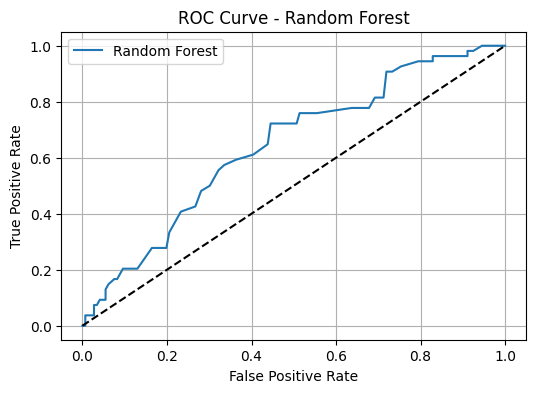

In [14]:

# ROC Curve
y_prob_rf = rf.predict_proba(X_test_scaled)[:, 1]
fpr, tpr, _ = roc_curve(y_test, y_prob_rf)

plt.figure(figsize=(6,4))
plt.plot(fpr, tpr, label='Random Forest')
plt.plot([0,1], [0,1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Random Forest')
plt.legend()
plt.grid()
plt.show()